# 자기회귀과정 모델링

MA(q) 프로세스:
- 현잿값이 현재 오차 항과 과거 오차 항에 선형적으로 의존.
- q 단계 이상의 미래를 예측하고자 했으나, 데이터 집합에서 오차 항을 확인할 수 없었음. 
- 재귀적으로만 추정할 수 있는 경우, 예측 결과로서 수열의 **평균값**만 얻을 수 있을 뿐.
- ACF 도식을 확인해 정상적 MA(q) 차수를 결정함.
    - 자기상관계수는 lag q 까지만 유의할 것이라는 한계.
    - **다만**, 자기상관계수가 천천히 감소하거나 사인 곡선 패턴을 보이는 경우, 자기회귀과정이 내제되어 있을 수 있음.


이번 챕터 다룰 내용:
- 자기회귀과정
- 편자기상관함수 (partial autocorrelation function; PACF) & 데이터 집합에 내재된 자기회귀과정의 차수를 찾아봄.
- AR(p) 모델을 활용해 예측을 수행.

# 5.1 소매점의 주간 평균 유동인구 예측

많은 사람이 방문 할 예정이면 직원을 늘리고, 방문객이 적으면 직원을 감축하고

In [ ]:
import pandas as pd
#file name: foot_traffic.csv
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/foot_traffic.csv')

df.head()

,foot_traffic
0,500.496714
1,500.522366
2,501.426876
3,503.295990
4,504.132695


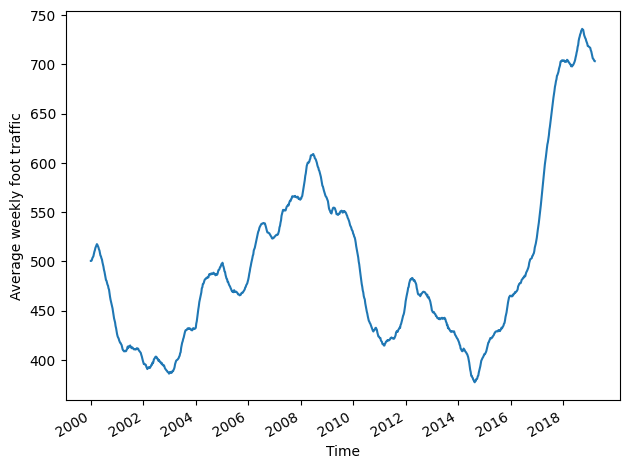

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df['foot_traffic'])
ax.set_xlabel('Time')
ax.set_ylabel('Average weekly foot traffic')

plt.xticks(np.arange(0, 1000, 104), np.arange(2000, 2020, 2))
# 0~1000전까지 104 간격으로 숫자 생성
# 데이터가 주 단위라면, 1년 = 52주; 104 = 2년치
# 2년마다 눈금을 찍겠다.

# 2000~2020까지 2씩 증가

fig.autofmt_xdate()
plt.tight_layout()

주간 평균 유동인구를 예측하려면 기반 프로세스를 파악해야 함.
 - 확률보행인지, 이동평균과정인지 확인.

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['foot_traffic'])

print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -1.1758885999240718
p-value: 0.6838808917896202


# 5.2 자기회귀과정 정의
- 예측값이 이전 값에만 선형적으로 의존한다고 가정.
- 변수가 자기 자신에게 회귀하는 것.